# Load in Packages

In [63]:
import numpy as np
import matplotlib as mpl
#mpl.use('TkAgg')
import matplotlib.pyplot as plt
import matplotlib.colors as col
from matplotlib.colors import PowerNorm
from matplotlib.patches import Rectangle
from matplotlib.ticker import FormatStrFormatter
from skimage.draw import disk
from scipy.optimize import curve_fit
from scipy import signal
from scipy.fft import fft, fftshift
#from lmfit import Parameters, minimize, report_fit
from obspy.imaging.cm import viridis_white
import cmocean
import xarray as xr
from math import nan
import multiprocessing

from arpes_tools import mpes
from arpes_tools.loader import DataLoader
from arpes_tools.mpes import cmap_LTL, cmap_LTL2
#from gui import main, launch_gui_v0

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load the Data
### Specify Filename and Path. Load the Data

In [65]:
# Specify datapath, filename, and [Energy (eV), Delay (fs)] offsets to load.

#data_path = 'R:\Lawson\Data\metis'
data_path = '/Users/lawsonlloyd/Desktop/Data/metis'

# CrSBr
filename, offsets = 'Scan162_RT_120x120x115x50_binned.h5', [0.8467, -120]

#  Load the Data
data_loader = DataLoader(data_path + '//' + filename, offsets = offsets)
I = data_loader.load()

The data shape is: (120, 120, 115, 50)
"/Users/lawsonlloyd/Desktop/Data/metis//Scan162_RT_120x120x115x50_binned.h5" has been loaded! Happy Analysis...


### Generate Normalized and Difference Data


In [66]:
# Truncate and Normalize Data, if desired.

# Normalize Each Time Step to the Total Volume Counts, if desired
I = I / I.sum(dim=('kx','ky','E'))

# Generate Difference Data (Pos - Neg Delay Times), if desired.
if "delay" in I.dims:
    #I = I.loc[{"delay":slice(-400,1000)}]
    I_res = I[:, :, :,1:-1]
    I_res = I_res/np.max(I_res)
    I_diff = I_res - I_res.loc[{"delay":slice(-250,-100)}].mean(dim="delay") #Create Different Data
    I_diff = I_diff/np.max(I_diff)
else:
    I_res = I/np.max(I)


/var/folders/f3/xrt6qd790rv6qc6bwc24py7m0000gn/T/ipykernel_80092/1644867192.py:10: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  line2.set_xdata(1)


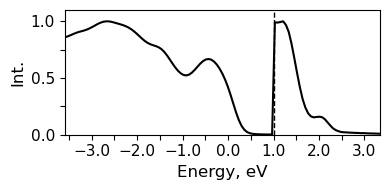

In [136]:
edc = mpes.get_edc(I, (0,0), (.5, .5), E_enhance = 0)

fig, ax = plt.subplots(1,1, figsize=(4,2))
#ax = ax.flatten()
_, _, line, line2 = mpes.plot_edc(I_res, (0,0), (.5, .5), E_enhance = None, fig = fig, ax = ax, norm_trace = True)

ydata = mpes.get_edc(I_res, (0,0), (5, 5), E_enhance = 1)
line
line[0].set_ydata(ydata)
line2.set_xdata(1)


In [22]:
ax[0]

<Axes: >

# Analysis and Visualization
### Launch Interactive GUI

In [ ]:
#%matplotlib qt

#main(I_res, title=f'{filename}')

# run the following in terminal:
# 
# start python launch_gui_v0.py (Windows)
# or
# python launch_gui_v0.py & (mac)

TypeError: 'module' object is not callable

### Plot Momentum Maps at Constant Energy

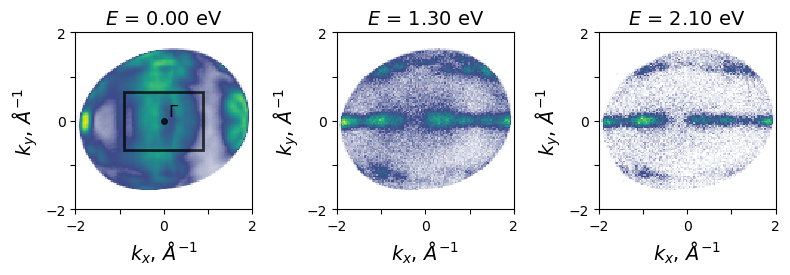

In [7]:
%matplotlib inline
cmap_plot = cmap_LTL

E, E_int = [0, 1.3, 2.1], .15
#delays, delay_int = 500, 1000

fig, ax, im = mpes.plot_momentum_maps(
    I_res, E=E, E_int=E_int, delays=500, delay_int=1000,
    cmap=cmap_LTL, scale=[0, 1], 
    fontsize=14, figsize=(8, 6), colorbar=False, panel_labels = False
)

mpes.overlay_bz('rectangular', 3.508, 4.763, ax[0], 'black', rotation_deg = 0, repeat = 0)
#mpes.save_figure(fig, name = f'scan186', image_format = 'svg')

### Energy vs Momentum: Bandstructure Plots

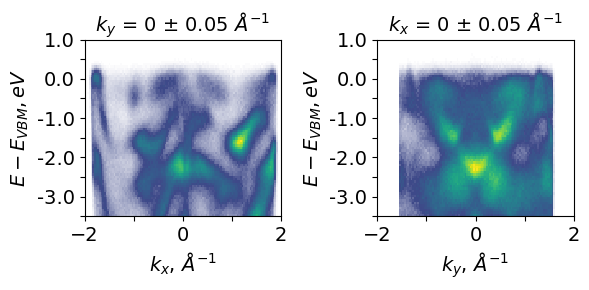

In [8]:
fig, ax = plt.subplots(1, 2, gridspec_kw={'width_ratios': [1, 1]})
fig.set_size_inches(6, 3, forward=False)
ax = ax.flatten()
fontsize = 14

# Plot kx-E frame
(kx, ky), (kx_int, ky_int) = (0, 0), (0.1, 0.1) # Central (kx, ky) point and k-integration
mpes.plot_kx_frame(
    I_res, ky, 0.1, delays=[-200], delay_int=200,
    subtract_neg=False,
    fig = fig, ax = ax[0],
    cmap = cmap_LTL, scale=[0,1], energy_limits=[-3.5, 1]
)

# Plot ky-E frame
(kx, ky), (kx_int, ky_int) = (0, 0), (0.1, 0.1) # Central (kx, ky) point and k-integration
kyfr = mpes.plot_ky_frame(
    I_res, kx, 0.1, delays=[-200], delay_int=200,
    subtract_neg=False,
    fig = fig, ax = ax[1],
    cmap = cmap_LTL, scale=[0,1], energy_limits=[-3.5, 1]
)

### Overview Plot

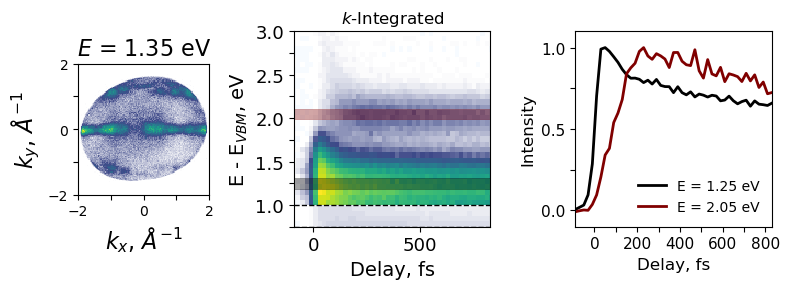

In [67]:
%matplotlib inline
fig, axs = plt.subplots(1, 3, gridspec_kw={'width_ratios': [1, 1.5, 1.5], 'height_ratios':[1]})
fig.set_size_inches(8, 3, forward=False)
axs = axs.flatten()

# Plot momentum map
mpes.plot_momentum_maps(
    I_res, E=1.35, E_int=.2, delays=500, delay_int=1000,
    fig = fig, ax = axs[0],
    cmap=cmap_LTL,
    panel_labels=False, fontsize=16)

# Plot waterfall
(kx, ky), (kx_int, ky_int) = (0, 0), (4, 4) # Central (kx, ky) point and k-integration
mpes.plot_waterfall(
    I_res, kx, kx_int, ky, ky_int,
    fig = fig, ax = axs[1], subtract_neg=True, neg_delays=[-300,-100],
    cmap=cmap_LTL2, scale=[-1,1], energy_limits=[0.75, 3], E_enhance = 1
)

# Plot time traces
E, E_int = [1.25, 2.05], .12 # Energies for Plotting Time Traces ; 1st Energy for MM
(kx, ky), (kx_int, ky_int) = (0, 0), (4, 4) # Central (kx, ky) point and k-integration
norm_trace, subtract_neg, neg_delays = True, True, [-300, -100]
mpes.plot_time_traces(
    I_res, E, E_int, (kx, ky), (kx_int, ky_int),
    norm_trace, subtract_neg, neg_delays,
    fig = fig, ax = axs[2],
    colors = ['black', 'maroon'],
    fontsize=12
)
axs[2].set_ylim(-0.1, 1.1)

for i in np.arange(len(E)):
    mpes.add_rect(500, 2000, E[i], E_int, axs[1], edgecolor=colors[i], facecolor=colors[i], alpha = 0.35)

#mpes.save_figure(fig, name = f'test', image_format = 'pdf')

fig.tight_layout()

### Plot & Fit Time Traces


Fit Results for model: biexp
----------------------------------------
A          =     1.1756 ±  0.1548
tau_decay1 =    29.4001 ±  4.7825
B          =     0.8179 ±  0.0151
tau_decay2 =  2927.1500 ± 304.5556
----------------------------------------

Fit Results for model: exp_rise_monoexp_decay
----------------------------------------
A          =     1.2752 ±  0.0617
tau_rise   =   117.3834 ± 10.3974
tau_decay1 =  1470.3545 ± 165.6327
----------------------------------------


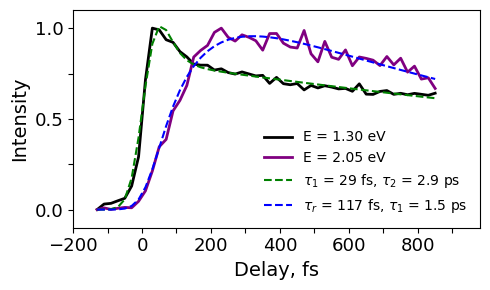

In [68]:
E, E_int = [1.3, 2.05], .15 # Energies for Plotting Time Traces ; 1st Energy for MM
(kx, ky), (kx_int, ky_int) = (0, 0), (4, 4) # Central (kx, ky) point and k-integration

norm_trace = True
subtract_neg = True
neg_delays = [-280, -120]

convolve = True
fwhm_IRF = 80
sigma_IRF = fwhm_IRF/2.355

fig, axs = plt.subplots()
fig.set_size_inches(5, 3, forward=False)
#axs = axs.flatten()

mpes.plot_time_traces(
    I, E, E_int, (kx, ky), (kx_int, ky_int),
    norm_trace, subtract_neg, neg_delays,
    fig = fig, ax = axs,
    colors = ['black', 'purple'],
    fontsize=14
)

### Do a Fitting: Choose model (input as string, e.g. 'monoexp') and input fit parameters (p0, bounds etc.)
delay_limits = (-200, 980)
delay_axis_1 = I.delay.loc[{"delay":slice(delay_limits[0], delay_limits[1])}].values

# Curve 1
time_trace = mpes.get_time_trace(I, E[0], E_int, (kx, ky), (kx_int, ky_int), norm_trace = True, subtract_neg = True, neg_delays = neg_delays)
time_trace = time_trace.loc[{"delay":slice(delay_limits[0], delay_limits[1])}].values

model = 'biexp'
p0 = [1, 100, 1, 1000]
lower_bounds, upper_bounds = (0, 0, 0, 0), (10, 5000, 10, 20000)
#model = 'monoexp'
#p0 = [1, 100]
#lower_bounds, upper_bounds = (0, 0), (10, 5000)
popt1, pcov, fit_curve_1 = mpes.fit_time_trace(model, delay_axis_1, time_trace, p0, [lower_bounds, upper_bounds], convolve = convolve, sigma_IRF = sigma_IRF)
params_ex, label_ex = mpes.print_fit_results(model, popt1, pcov)

delay_limits = (-200, 980)
delay_axis_2 = I.delay.loc[{"delay":slice(delay_limits[0], delay_limits[1])}].values

# Curve 2
time_trace = mpes.get_time_trace(I, E[1], E_int, (kx, ky), (kx_int, ky_int), norm_trace = True, subtract_neg = True, neg_delays = neg_delays)
time_trace = time_trace.loc[{"delay":slice(delay_limits[0], delay_limits[1])}].values

model = 'exp_rise_monoexp_decay'
p0 = [2, 10, 120] #C, tau_rise, tau_decay1)
lower_bounds, upper_bounds = (0, 0, 0), (10, 2000, 10000)

#model = 'biexp'
#p0 = [1, 100, 1, 3000]
#lower_bounds, upper_bounds = (0, 0, 0, 0), (10, 5000, 10, 10000)

#model = 'monoexp'
#p0 = [1, 100]
#lower_bounds, upper_bounds = (0, 0), (10, 5000)

popt2, pcov, fit_curve_2 = mpes.fit_time_trace(model, delay_axis_2, time_trace, p0, [lower_bounds, upper_bounds], convolve = convolve, sigma_IRF = sigma_IRF)
params_cbm, label_cbm = mpes.print_fit_results(model, popt2, pcov)

#conv_model = mpes.make_convolved_model(mpes.exp_rise_monoexp_decay, delay_axis, 40)
#init_curve = conv_model(delay_axis, *p0)

# Plot Fits
axs.plot(delay_axis_1, fit_curve_1, linestyle = 'dashed', color = 'green', label = label_ex)
axs.plot(delay_axis_2, fit_curve_2, linestyle = 'dashed', color = 'blue', label = label_cbm)
axs.legend(frameon=False)
axs.set_ylim(-0.1,1.1)
axs.set_xlim(-200,delay_limits[1])
fig.tight_layout()

## Axes Calibration
### Define E = 0 wrt VBM

E_VBM = 0.005 +- 0.004 eV


(-1.0, 1.0)

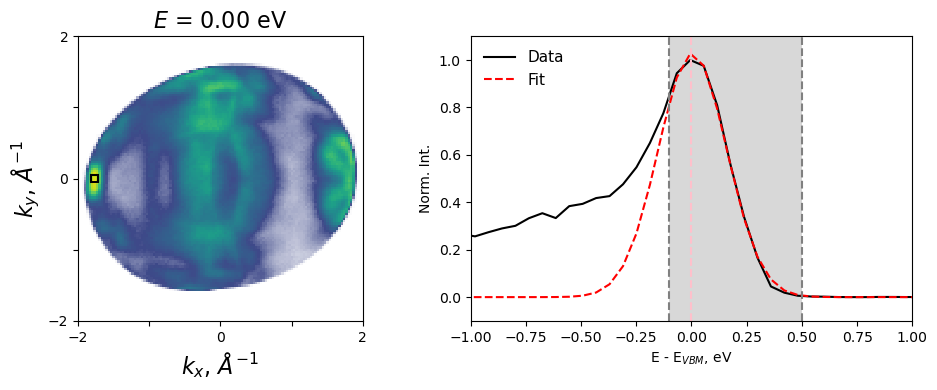

In [39]:
#%% Define E = 0 wrt VBM

%matplotlib inline

fig, ax = plt.subplots(1, 2, gridspec_kw={'width_ratios': [1, 1], 'height_ratios':[1]})
fig.set_size_inches(10, 4, forward=False)
ax = ax.flatten()

figure_file_name = 'vbm'
save_figure = False

### Plot EDCs at GAMMA vs time

(kx, ky), k_int = (-1.95*.91, 0), 0.1

delay, delay_int = -100, 200

edc_gamma = mpes.get_edc(I_res, (kx, ky), (k_int, k_int), delay=-200, delay_int=200)
edc_gamma = edc_gamma/np.max(edc_gamma)

mpes.plot_momentum_maps(
    I_res, E=0, E_int=.1, delays=500, delay_int=1000,
    fig = fig, ax = ax[0],
    cmap=cmap_LTL, scale=[0, 1],
    fontsize=16, figsize=(8, 6), colorbar=False, panel_labels = False
)
    
energy_window = [-0.1, 0.5]
p0 = [1, .02, 0.4, 0] # Fitting params initial guess [amp, center, width, offset]

mpes.find_E0(edc_gamma, energy_window, p0, fig, ax)

# cbar_ax = fig.add_axes([.51, 0.275, 0.025, 0.5])
rect = (Rectangle((kx-k_int/2, ky-k_int/2), k_int, k_int, linewidth=1.5,\
                         edgecolor='k', facecolor='None'))

rect1 = (Rectangle((energy_window[0], -.5), (energy_window[1]-energy_window[0]), 2, linewidth=1.5,\
                         edgecolor='none', facecolor='grey', alpha=0.3))

fig.axes[0].add_patch(rect)
fig.axes[1].add_patch(rect1)
ax[1].set_ylim(-0.1,1.1)
ax[1].axvline(energy_window[0], color = 'grey', linestyle = 'dashed')
ax[1].axvline(energy_window[1], color = 'grey', linestyle = 'dashed')
ax[1].axvline(0, color = 'pink', linestyle = 'dashed')

ax[1].set_xlim(-1, 1)


### Define t0 from Signal Rise


t0 = 0.2 +/- 2.9 fs
width = 22.9 +/- 5.8 fs


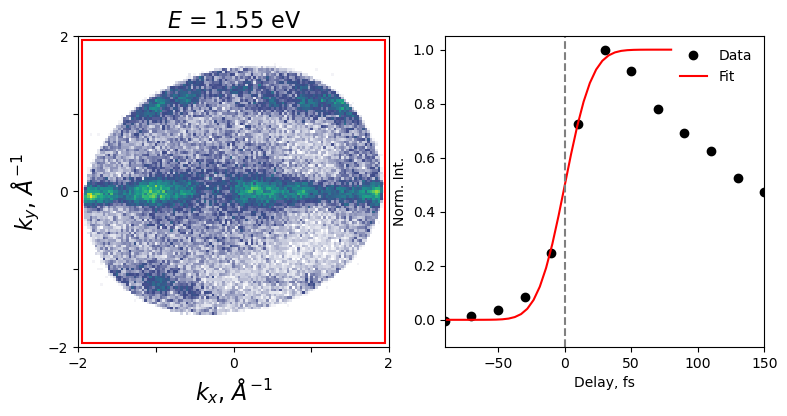

In [29]:
#%% Define t0 from Exciton Rise

fig, ax = plt.subplots(1, 2, gridspec_kw={'width_ratios': [1, 1], 'height_ratios':[1]})
fig.set_size_inches(8, 4, forward=False)
ax = ax.flatten()

figure_file_name = 'define_t0'
save_figure = False

### Plot EDCs at GAMMA vs time

(kx, ky), (kx_int, ky_int) = (0, 0), (3.9, 3.9)
#(kx, ky), (kx_int, ky_int) = (0, .7), (1.5, 0.5)
E, E_int = 1.55, 0.1
delay_limits = [-150, 80]

mpes.plot_momentum_maps(
    I_res, E=E, E_int=E_int, delays=200, delay_int=700,
    fig = fig, ax = ax[0],
    cmap=cmap_LTL, scale=[0, 1],
    fontsize=16, figsize=(8, 6), colorbar=False, panel_labels = False
)
    
rect = (Rectangle((kx-kx_int/2, ky-ky_int/2), kx_int, ky_int, linewidth=1.5,\
                         edgecolor='red', facecolor='None'))
fig.axes[0].add_patch(rect)

trace_ex = mpes.get_time_trace(I_res, E, E_int, (kx, ky), (kx_int, ky_int),  norm_trace = True, subtract_neg = True, neg_delays = (-350, -100))
mpes.find_t0(trace_ex, delay_limits, fig=fig, ax=ax)

if save_figure is True:
    mpes.save_figure(fig, name = f'test', image_format = 'pdf')